# Principal Component Analysis (PCA)
This notebook was written by Ptrong (the author) for learning purposes only. Its content is based on the course of the same name, delivered by **Imperial College London** on the *Coursera* platform.

>> "With profound gratitude, I acknowledge the individual delivering this course and their affiliates, and I also deeply recognize the interwoven fates, causes, and effects that nurture all and have granted me the opportunity to partake in this valuable reservoir of knowledge — especially this course."
___
Table of contents

[**Chapter 1:** Statistics of Datasets](#chapter-1-statistics-of-datasets)      
[**Chapter 2:** Inner Products](#chapter-2-inner-products)      
[**Chapter 3:** Orthogonal Projections](#chapter-3-orthogonal-projections)     
[**Chapter 4:** Principal Component Analysis](#chapter-4-principal-component-analysis)        


## Chapter 1: Statistics of Datasets

### Mean of a dataset
We can calculate the mean of a dataset $\mathcal{D} = \left\{x_1, ..., x_N \right\}$ as:
$$
E[\mathcal{D}] = \frac{1}{N}\sum_{n=1}^{N}x_n
$$
*For example:* we roll five dice with $\mathcal{D}' = \{1, 2, 4, 6, 6 \}$, then we have the expected value of this dataset is
$$
E[\mathcal{D}'] = \frac{1+2+4+6+6}{5} = \frac{19}{5} = 3.8
$$


**PROBLEM:** Assume that we know the mean $\bar{x}_{n-1}$ of a dataset $\mathcal{D}_{n-1}$ with $n-1$ data points. Now, suppose that we collect another data point, which we denote by $x_{*}$. Therefore, the new dataset is $\mathcal{D}_{n} = \mathcal{D}_{n-1} \cup \{x_{*}\}$ ,i.e., we add $x_{*}$ to the dataset $\mathcal{D}$. <br>

*SOLUTION:*<br>
We have the mean value of the original dataset $\mathcal{D}_{n-1}$ as
$$
\bar{x}_{n-1} = \frac{1}{n-1}\sum_{i=1}^{n-1}x_{i} \\
\implies \sum_{i=1}^{n-1}x_{i} = (n-1)\bar{x}_{n-1} \tag{1}
$$
then if we add $x_{*}$ to our dataset. The new dataset is $\mathcal{D}_{n} = \mathcal{D}_{n-1} \cup \{x_{*}\}$ with $n$ data points. Therefore, the new mean value of this dataset can be calculated as
$$
\bar{x}_{n} = \frac{1}{n}\sum_{i=1}^{n}x_{i}
$$
when calculating the sum of all data points, we can rewrite as
$$
\sum_{i=1}^{n}x_{i} = \sum_{i=1}^{n-1}x_{i} + x_{*}
$$
the new mean value can be redefined as follow
$$
\bar{x}_{n} = \frac{1}{n}\left(\sum_{i=1}^{n-1}x_{i} + x_{*}\right)
$$
then we can substitude the $\sum_{i=1}^{n-1}x_{i}$ from equation $(1)$ and have
$$
\begin{align*}
\bar{x}_n &= \frac{1}{n}((n-1)\bar{x}_{n-1} + x_{*}) \\
\implies \bar{x}_n &= \frac{(n-1)\bar{x}_{n-1} + x_{*}}{n} \\
\implies \bar{x}_n &= \bar{x}_{n-1} + \frac{1}{n}(x_{*} - \bar{x}_{n-1})
\end{align*}
$$

### Variance of one-dimensional datasets
We consider the two datasets, which are $\mathcal{D}_1$ and $\mathcal{D}_2$ as
- $\mathcal{D}_1 = \{1, 2, 4, 5\}$, $E[\mathcal{D}_1] = 3$
- $\mathcal{D}_2 = \{-1, 3, 7\}$, $E[\mathcal{D}_2] = 3$

we are going to calculate the average squared distance of $\mathcal{D}_1$ from the mean and for $\mathcal{D}_2$ from the same mean:
- $\mathcal{D}_1: \frac{(1-3)^2+(2-3)^2+(4-3)^2+(5-3)^2}{4} = \frac{4+1+1+4}{4} = \frac{10}{4}$
- $\mathcal{D}_2: \frac{(-1-3)^2+(3-3)^2+(7-3)^2}{3} = \frac{16+0+16}{3} = \frac{32}{3}$

then we can formalise the average squared distance of a dataset (or *variance*) $\{x_1, ..., x_N\}=: X$ as
$$
Var[X] = \frac{1}{N}\sum_{n=1}^{N}(x_n - \mu)^2
$$
in which $\mu = E[X]$. The variance is the average squared distance therefore it can not be a negative number. So we can also take the squared root of the variance, called *standard deviation*. The standard deviation is expressed in the same units as the mean value whereas the variance is expressed in squared units. Therefore, when we talk about spread of the data, we usually look at standard deviations

**PROBLEM**: Assuming we have mean $\bar{x}_{n-1}$ and variance $\sigma_{n-1}^{2}$ for some dataset $\mathcal{D}_{n-1}$ with $n-1$ samples. What would be the variance $\sigma_{n}^{2}$ if we add a new element $x_{*}$ to the dataset (assuming we have computed the new sample mean $\bar{x}_{n}$)?

*SOLUTION*: We recall some formulae that we have had
- $\bar{x}_n = \bar{x}_{n-1} + \frac{1}{n}(x_{*}-\bar{x}_{n-1}) \quad \text{(1)}$
- for dataset $\mathcal{D}_{n-1}$, we have $\sigma_{n-1}^{2} = \frac{1}{n-1}\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 \quad \text{(2)}$
- for dataset $\mathcal{D}_{n}$, we have $\sigma_{n}^{2} = \frac{1}{n}\sum_{i=1}^{n}(x_{i}-\bar{x}_{n})^2 \quad \text{(3)}$

from $(1)$ we have
$$
\left\{
\begin{array}{l}
\bar{x}_n-\bar{x}_{n-1}=\frac{1}{n}(x_{*}-\bar{x}_{n-1})\\
\bar{x}_{n-1}-\bar{x}_n=-\frac{1}{n}(x_{*}-\bar{x}_{n-1})
\end{array}
\right. \\
\begin{align*}
\implies x_{*}-\bar{x}_{n} &= x_{*} - [\bar{x}_{n-1} + \frac{1}{n}(x_{*} - \bar{x}_{n-1})] \\
&= x_{*}-\bar{x}_{n-1} - \frac{x_{*}-\bar{x}_{n-1}}{n} \\
&= \frac{n-1}{n}(x_{*}-\bar{x}_{n-1})
\end{align*}
$$
from $(2)$ we have
$$
\sigma_{n-1}^{2}(n-1) = \sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2
$$
then we can adjust the formula $(3)$ as
$$
\begin{align*}
\sigma_{n}^{2} &= \frac{1}{n}\sum_{i=1}^{n}(x_{i}-\bar{x}_{n})^2 \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n})^2 +(x_{*}-\bar{x}_{n})^2\right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}[(x_{i}-\bar{x}_{n-1})+(\bar{x}_{n-1}-\bar{x}_{n})]^2+(x_{*}-\bar{x}_{n})^2\right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 + 2(\bar{x}_{n-1}-\bar{x}_{n})\underbrace{\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})}_{=0}+\sum_{i=1}^{n-1}(\bar{x}_{n-1}-\bar{x}_{n})^2 + (x_{*}-\bar{x}_{n})^2 \right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 + (n-1-1+1)(\bar{x}_{n-1}-\bar{x}_{n})^2 + (x_{*}-\bar{x}_{n})^2\right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 + (n-1)(\bar{x}_{n-1}-\bar{x}_{n})^2 + (x_{*}-\bar{x}_{n})^2\right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 + (n-1)\left[-\frac{1}{n}(x_{*}-\bar{x}_{n-1})\right]^2 + \left[\frac{n-1}{n}(x_{*}-\bar{x}_{n-1})\right]^2\right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 + (n-1)\frac{(x_{*}-\bar{x}_{n-1})^2}{n^2} + (x_{*}-\bar{x}_{n-1})^2\frac{(n-1)^2}{n^2}\right] \\
&= \frac{1}{n}\left[\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2 + \frac{(n-1)}{n}(x_{*}-\bar{x}_{n-1})^2\right] \\
&= \frac{1}{n}\left[\underbrace{\sum_{i=1}^{n-1}(x_{i}-\bar{x}_{n-1})^2}_{\sigma_{n-1}^{2}(n-1)} + \underbrace{\frac{(n-1)}{n}(x_{*}-\bar{x}_{n-1})}_{x_{*} - \bar{x}_{n}}(x_{*}-\bar{x}_{n-1})\right] \\
&= \frac{1}{n}\left[\sigma_{n-1}^{2}(n-1) + (x_{*}-\bar{x}_{n})(x_{*}-\bar{x}_{n-1})\right] \\
&= \frac{n-1}{n}\sigma_{n-1}^{2} + \frac{1}{n}(x_{*}-\bar{x}_{n-1})(x_{*}-\bar{x}_{n})
\end{align*}
$$
Finally, we have
$$
\boxed{\sigma_{n}^{2} = \frac{n-1}{n}\sigma_{n-1}^{2} + \frac{1}{n}(x_{*}-\bar{x}_{n-1})(x_{*}-\bar{x}_{n})}
$$

### Reading: Symmetric, positive definite matrices
- A matrix $\mathbf{M}$ is **symmetric** if $\mathbf{M} = \mathbf{M}^{T}$.
- A symmetric matrix $\mathbf{M}$ is **positive-definite** if $\mathbf{z}^{T}\mathbf{M}\mathbf{z}>0$, or in matrix form,
$$
\begin{bmatrix}z_1&z_2&\cdots&z_n\end{bmatrix}
\begin{bmatrix}M_{11}&M_{12}&\cdots&M_{1n}\\M_{21}&M_{22}&\ddots&\vdots\\\vdots&\ddots&\ddots&\vdots\\M_{n1}&M_{n2}&\cdots&M_{nm}\end{bmatrix}
\begin{bmatrix}z_1\\z_2\\\vdots\\ z_n\end{bmatrix} >0
$$
for a real column vector $z\neq0$.

An example of symmetric and positive definite matrix is $\begin{bmatrix}7&1\\1&2\end{bmatrix}$.

The eigenvalues of symmetric positive matrices are positive. To see this, consider a symmetric positive-definite matrix $\mathbf{M}$. Let $\lambda$ denote an eigenvalue of M, then we have $\mathbf{M}\mathbf{v} = \lambda\mathbf{v}$ where $\mathbf{v}$ is corresponding eigenvector. When $\mathbf{M}$ is positive-definite, we have $\mathbf{v}^T\mathbf{M}\mathbf{v} = \lambda\mathbf{v}^T\mathbf{v}>0$. Since $\mathbf{v}^{T}\mathbf{v}\geq0$, it follows that the $\lambda$ must be positive.

> The **covariance matrix** is *symmetric* and *positive-define*.

We can prove as shown below:

It is also positive-definite. Too see this, let's take a step back and look at the covariance matrix for a dataset of two independent random variables $x$ and $y$. We have created a few visualisations for a 2-dimensional dataset with the different covariance matrices. In the figure, the cross represents the individual examples in the dataset. The gray dashed lines represent the sample mean of the dataset in each dimension. The blue lines show the sample variance in each dimension. Finally, the purple arrows show the eigenvecotrs for the covariance matrix in each dimension.

In the first example, we show a dataset with the covariance matrix:
$$
\begin{bmatrix}cov(x, x)&cov(x, y)\\cov(y, x)&cov(y, y)\end{bmatrix} =\begin{bmatrix}7.5&0\\0&1.1\end{bmatrix}
$$
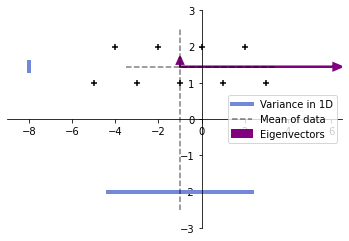

In the second example, we use the following covariance matrix:
$$
\begin{bmatrix}cov(x, x)&cov(x, y)\\cov(y, x)&cov(y, y)\end{bmatrix}=\begin{bmatrix}1.11&0\\0&7.5\end{bmatrix}
$$
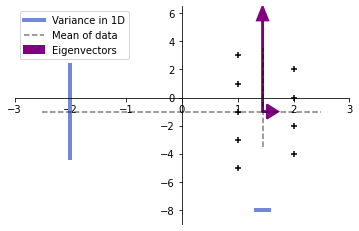

In both cases the covariance matrix the two variables are independent since $cov(x, y) = cov(y, x) = 0$. As a result, the covariance matrices are diagonal. The diagonal entries are the variancews for each of the variables, and are always positive. Notice that the eigenvalues of the matrix are equal to the variances.

The eigenvectors are orthogonal to one another (because of the symmetry of the matrix, see this derivation for more information) and represent the different directions in which the data varies. The direction in which the variables varie the *most* coincide with the eigenvectors.

For the two examples of datasets with independent variables, the eigenvectors are along the $x$ and $y$ axes. What happens when $cov(x, y) \neq 0$?

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
fig, ax = plt.subplots()

# The datatset to be plotted. You can add and remove points 
# from the array to create a dataset with cov(x, y) != 0
data = np.array([[1,1],
                [-3,-3],
                [2,2],
                [0,2],
                [-2,0],
                [1,3],
                [4,4]])
mean_data = np.mean(data, axis=0)
# The following two lines will generate a plot similar to the figures above.
create_plot(data)
plt.show()

### Variance of higher-dimensional datasets
We have different datasets with the same variance of $x$ and $y$. Therefore, we can not compare them together. Instead of using seperately variance of $x$ and $y$, we consider to use **the covariance of the data**, which is defined as follows:
$$
\boxed{cov[x, y]=E[(x-\mu_{x})(y-\mu_{y})]}
$$
in which:
- $\mu_{x}=E[x]$
- $\mu_{y}=E[y]$

For the 2D data, ưe can obtain four quantities of interest: $var[x]$, $var[y]$, $cov[x, y]$, and $cov[y, x]$. We summarise these values in this matrix the covariance matrix with four entries:
$$
\begin{bmatrix}var[x]&cov[x,y]\\cov[y,x]&var[y]\end{bmatrix}
$$
If 
- $cov[x, y] > 0$, then on average the $y$ value increases if we increase $x$.
- $cov[x, y] < 0$, then the $y$ value decreases if we increase $x$ on average.
- $cov[x, y] = 0$, then $x$ and $y$ have nothing to do with each other $\rightarrow$ they are uncorrelated
> The covariance matrix is always a symmetric positive definite matrix with the variances on the diagonal and the cross covariances on the off diagonals.

We have the covariance matrix of a three-dimensional datasets $(x, y, z)$ is $3\times3$ size:
$$
\begin{bmatrix}var[x]&cov[x, y]&cov[x, z]\\cov[y,x]&var[y]&cov[y, z]\\cov[z, x]&cov[z, y]&var[z]\end{bmatrix}
$$
Variances on the diagonal, cross-covariances on the off-diagonal.

If we looke at a dataset whose element are D-dimensional vectors $\mathbf{x}=\begin{bmatrix}x_1\\\vdots\\x_D\end{bmatrix}$ or $\mathcal{D}=\{x_1,\cdots,x_N\}, x\in\mathbb{R}^{\mathcal{D}}$, we expect $\mathbf{D}\times\mathbf{D}$ on the size of the covariance matrix.
$$
var[D]=\frac{1}{N}\sum_{i=1}^{N}(x_{i}-\mu)(x_{i}-\mu)^{T}
$$

## Chapter 2: Inner Products

## Chapter 3: Orthogonal Projections

## Chapter 4: Principal Component Analysis